# Advanced Options for Portfolio Allocation Models

HARK's `RiskyAssetConsumerType` introduced consumers who can save in a risky asset as well as the risk-free asset. The `PortfolioConsumerType` models the same problem, but with additional "advanced" options. Using these options significantly increases the computational complexity of solving the model, so we recommend against using `PortfolioConsumerType` unless you are specifically interested in these features:

1. Sticky portfolio choice: agents can only change their portfolio allocation with some probability.
2. Discrete portfolio shares: agents have a finite menu of risky asset shares $s_t$, rather than a continuous choice.

In [1]:
from time import time

import matplotlib.pyplot as plt

from HARK.models import RiskyAssetConsumerType, PortfolioConsumerType
from HARK.ConsumptionSaving.ConsPortfolioModel import init_portfolio
from HARK.utilities import plot_funcs, plot_func_slices

mystr = lambda number: f"{number:.4f}"

## Standard Portfolio Choice Model: `RiskyAssetConsumerType`

To begin, let's solve the standard `RiskyAssetConsumerType` as a comparitor for the advanced options below. The model is described in [this notebook](RiskyAssetConsumerType.ipynb).

In [2]:
# Adjust the default parameters for PortfolioConsumerType slightly
temp_params = init_portfolio.copy()
temp_params["cycles"] = 0  # infinite horizon
del temp_params["constructors"]  # don't overwrite these

In [3]:
# Make and solve a baseline risky asset consumer type
print("Now solving the baseline risky asset consumer's problem...")
BaseType = RiskyAssetConsumerType(**temp_params)
t0 = time()
BaseType.solve()
BaseType.unpack("cFunc")
BaseType.unpack("ShareFunc")
t1 = time()
print("Solving the baseline risky asset problem took " + mystr(t1 - t0) + " seconds.")

Now solving the baseline risky asset consumer's problem...
Solving the baseline risky asset problem took 1.1113 seconds.


## Advanced Portfolio Choice Model: `PortfolioConsumerType`

The most obvious comparison to make is to solve the *exact same* model again, but with `PortfolioConsumerType` rather than `RiskyAssetConsumerType`. Note that for the baseline type, we used the default parameter dictionary for `PortfolioConsumerType`, so this is an apples-to-apples comparison. When we plot the policy functions below, they *should* be identical.

In [4]:
# Make and solve the portfolio choice consumer type with default parameters
print("Now solving the advanced portfolio choice consumer's problem...")
PortfolioType = PortfolioConsumerType(cycles=0)
t0 = time()
PortfolioType.solve()
PortfolioType.unpack("cFuncAdj")
PortfolioType.unpack("ShareFuncAdj")
t1 = time()
print(
    "Solving the advanced portfolio choice problem took " + mystr(t1 - t0) + " seconds."
)

Now solving the advanced portfolio choice consumer's problem...
Solving the advanced portfolio choice problem took 10.5826 seconds.


Note that the policy functions have slightly different names for a `PortfolioConsumerType`: the suffix `Adj` has been appended, for "adjust". With the default parameters, the agents are free to adjust their portfolio allocation in every period, so these are the only functions that matter.

Let's compare the policy functions between the two models to verify that they're the same.

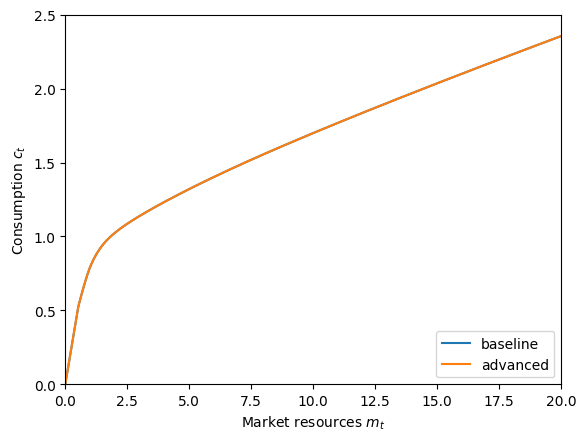

In [5]:
# Compare consumption functions
plt.ylim(0.0, 2.5)
plot_funcs(
    [BaseType.cFunc[0], PortfolioType.cFuncAdj[0]],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
    legend_kwds={"labels": ["baseline", "advanced"], "loc": 4},
)

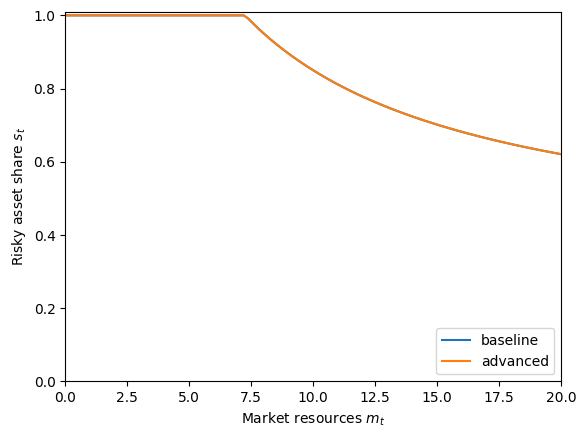

In [6]:
# Compare risky asset share functions
plt.ylim(0.0, 1.01)
plot_funcs(
    [BaseType.ShareFunc[0], PortfolioType.ShareFuncAdj[0]],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Risky asset share $s_t$",
    legend_kwds={"labels": ["baseline", "advanced"], "loc": 4},
)

I can't even see the baseline (blue) policy functions because they're fully covered up by the advanced (orange) functions. Great!

## Discrete Portfolio Share Choice

The first "advanced" option for `PortfolioConsumerType` is discrete risky asset shares. Recall that the agents are usually allowed to choose any risky asset share on the unit interval: $s_t \in [0,1]$. An alternative assumption is that there is a finite set $\mathbb{S}$ from which they can make their choice: $s_t \in \mathbb{S}$. If this is the case, then the first order condition for optimal risky asset share obviously does not apply. Instead, the optimal share is chosen by explicitly maximizing over the discrete options.

To model this feature, the parameter `DiscreteShareBool` should be set to `True`. The set $\mathbb{S}$ is determined by the constructed attribute `ShareGrid`. By default, `ShareGrid` is linearly spaced on $[0,1]$ with `ShareCount` nodes. The default `ShareCount` is $26$, so $\mathbb{S} = \left\{0, 0.04, 0.08, \cdots, 0.96, 1\right\}$. Because explicit value maximization is used, the parameter `vFuncBool` must be set to $True$ to use discrete portfolio shares.

In [7]:
# Create and solve the discrete choice type
DiscreteType = PortfolioConsumerType(cycles=0, DiscreteShareBool=True, vFuncBool=True)
print("Now solving a discrete choice portfolio problem...")
t0 = time()
DiscreteType.solve()
DiscreteType.unpack("cFuncAdj")
DiscreteType.unpack("ShareFuncAdj")
t1 = time()
print(
    "Solving an infinite horizon discrete portfolio choice problem took "
    + mystr(t1 - t0)
    + " seconds.",
)

Now solving a discrete choice portfolio problem...
Solving an infinite horizon discrete portfolio choice problem took 22.1888 seconds.


Now let's plot and compare the policy functions for the discrete choice problem to the continuous choice problem. We should expect that the risky asset share follows fairly closely to the continuous version, but as a discontinuous step function. Because the risky asset shares aren't *too* different, the consumption functions should be quite similar, but not the *same*.

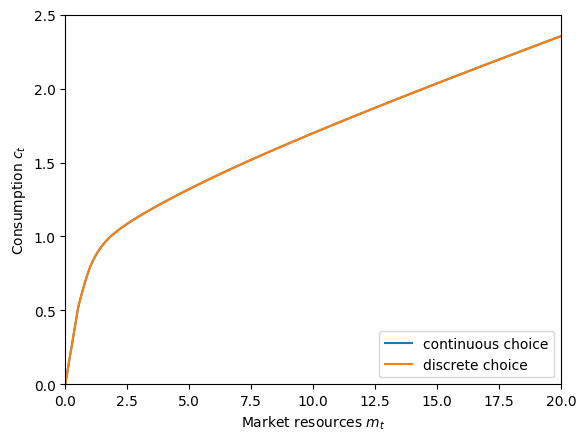

In [8]:
# Compare the consumption functions
plt.ylim(0.0, 2.5)
plot_funcs(
    [PortfolioType.cFuncAdj[0], DiscreteType.cFuncAdj[0]],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
    legend_kwds={"labels": ["continuous choice", "discrete choice"], "loc": 4},
)

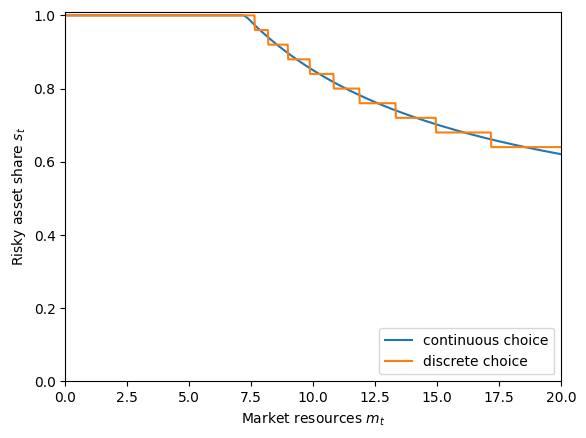

In [9]:
# Compare the risky asset share functions
plt.ylim(0.0, 1.01)
plot_funcs(
    [PortfolioType.ShareFuncAdj[0], DiscreteType.ShareFuncAdj[0]],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Risky asset share $s_t$",
    legend_kwds={"labels": ["continuous choice", "discrete choice"], "loc": 4},
)

Those consumption functions are so similar that you might not believe they're actually different, so let's zoom in on just the difference between the two.

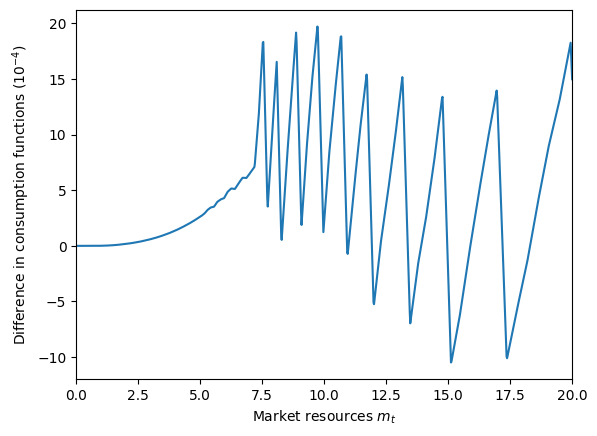

In [10]:
# Plot the difference between the discrete and continuous choice consumption functions
cDiff = lambda m: (DiscreteType.cFuncAdj[0](m) - PortfolioType.cFuncAdj[0](m)) * 10e4
plot_funcs(
    cDiff,
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Difference in consumption functions ($10^{-4}$)",
)

Now we can see that the consumption function for the discrete choice portfolio problem is *also* discontinuous-- barely. Each of the sharp drops in the difference between consumption functions corresponds to a discontinuity in the discrete share function because of its "step" form. Naturally, when one control changes discontinuously, the other must as well.

## Sticky Portfolio Share Choice

The second "advanced" extension for `PortfolioConsumerType` is "sticky" portfolio shares. Rather than being able to adjust their portfolio allocation each period, the agents have only a probability $\pi$ (called `AdjustPrb` in the code) of being able to reallocate their wealth between the risky and risk-free asset. Otherwise, their risky asset share $s_t$ remains at its value from the prior period.

The prior risky asset share $s_{t-1}$ thus becomes a decision-time state variable, at least for agents who cannot adjust their portfolio share. This is the major factor for why the `PortfolioConsumerType` takes so much longer to solve than an equivalent `RiskyAssetConsumerType`. That is, the "advanced" model treats the problem as having *two* state variables no matter what, and represents the consumption function for "suboptimal" outcomes in which the portfolio share is fixed *even if* it can always be adjusted.

In [11]:
# Make and solve a sticky portfolio choice consumer type
print("Now solving a portfolio choice problem with sticky portfolio shares...")
StickyType = PortfolioConsumerType(
    cycles=0, AdjustPrb=0.15
)  # only get to adjust 15% of the time!
t0 = time()
StickyType.solve()
StickyType.unpack("cFuncAdj")
StickyType.unpack("ShareFuncAdj")
StickyType.unpack("cFuncFxd")
StickyType.unpack("ShareFuncFxd")
t1 = time()
print(
    "Solving an infinite horizon sticky portfolio choice problem took "
    + mystr(t1 - t0)
    + " seconds.",
)

Now solving a portfolio choice problem with sticky portfolio shares...
Solving an infinite horizon sticky portfolio choice problem took 26.7473 seconds.


Let's compare the consumption functions and risky asset share functions for the sticky problem to the original one. We should expect them to be similar, but not quite the same.

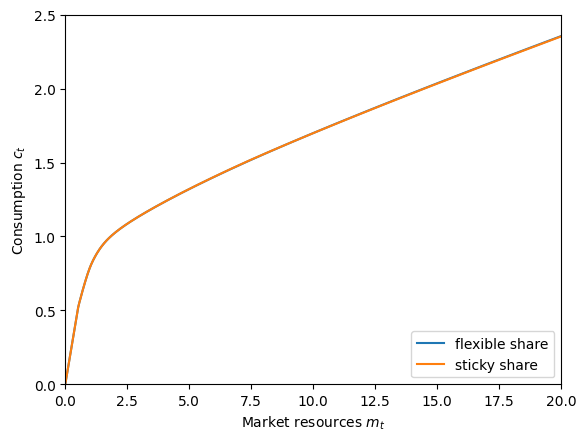

In [12]:
# Compare the sticky and flexible consumption functions
plt.ylim(0.0, 2.5)
plot_funcs(
    [PortfolioType.cFuncAdj[0], StickyType.cFuncAdj[0]],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
    legend_kwds={"labels": ["flexible share", "sticky share"], "loc": 4},
)

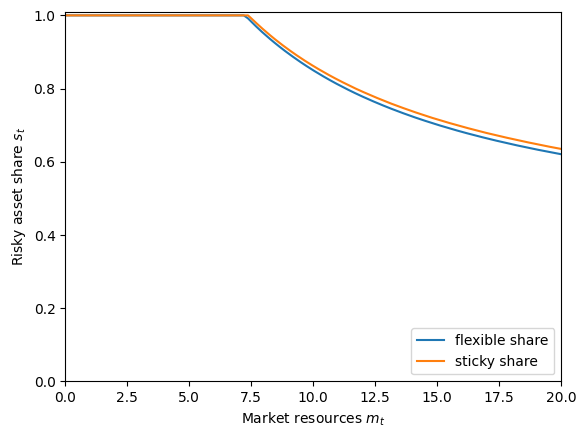

In [13]:
# Compare the sticky and flexible risky share functions
plt.ylim(0.0, 1.01)
plot_funcs(
    [PortfolioType.ShareFuncAdj[0], StickyType.ShareFuncAdj[0]],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Risky asset share $s_t$",
    legend_kwds={"labels": ["flexible share", "sticky share"], "loc": 4},
)

Where they differ, the optimal risky asset share in the sticky choice model is slightly higher than the flexible choice model. Why is that? With these parameters, consumers with high $m_t$ (i.e. above the point where they no longer put all of their wealth into the risky asset) plan to run their wealth down over time and be at lower $m_t$ in the future-- their "target" market resources are significantly lower. The optimal risky asset share is non-increasing in $m_t$, and the consumers know that they will be "stuck" with their chosen $s_t$ for 6-7 periods on average. They thus *overshoot* their risky asset share relative to the choice they would make if it could be updated *every* period, as they are making the choice for this period *and* (likely) the next several periods.

The consumption function in the sticky portfolio choice model isn't much different from the consumption function with flexible portfolio choice. Indeed, the consumption function when the agent *can't* update their share doesn't actually vary much by the portfolio share they're currently "stuck" at. Let's plot "slices" of that consumption function at different $s_t$ values:

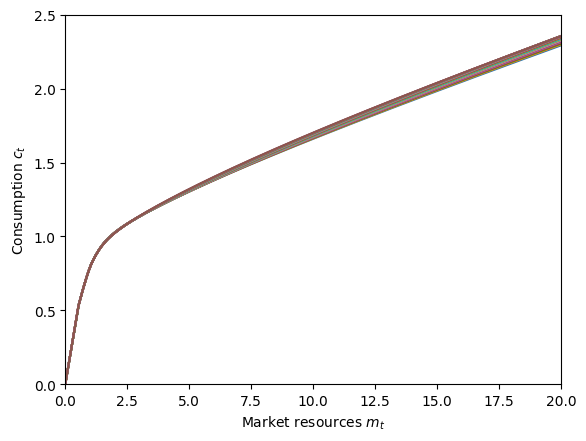

In [14]:
# Plot the "fixed share" consumption function at different levels of risky portfolio share
plt.ylim(0.0, 2.5)
plot_func_slices(
    StickyType.cFuncFxd[0],
    0.0,
    20.0,
    Z=StickyType.ShareGrid,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
)

The policy functions when the consumer can't adjust their share have the suffix `Fxd` (for "fixed") appended. We can also plot the risky asset share function when the agent can't adjust $s_t$, but it's not much to look at.

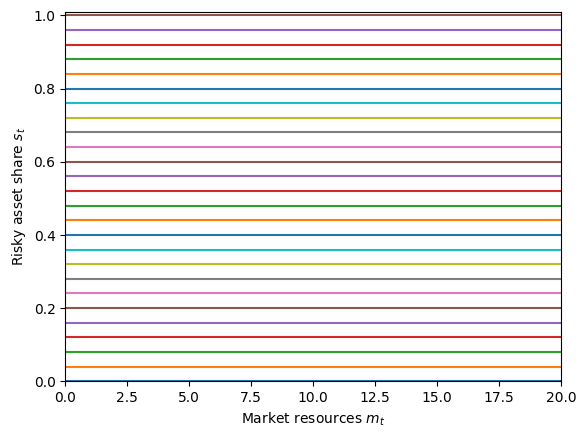

In [15]:
# Plot the "fixed share" risky share function at different levels of risky portfolio share
plt.ylim(0.0, 1.01)
plot_func_slices(
    StickyType.ShareFuncFxd[0],
    0.0,
    20.0,
    Z=StickyType.ShareGrid,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Risky asset share $s_t$",
)

Unsurprisingly, the risky asset share when risky asset share is fixed is... fixed.

As a final note, the two extensions can be *combined*: HARK can handle a specification in which the agent can only select among a discrete set of risky asset shares *and* only gets to update their portfolio allocation occasionally.